라이브러리 import 및 경로

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = 'C:/Users/jaeju/vscode/Kaggle/dataset/data.csv' 

In [34]:
df = pd.read_csv(path)

In [11]:
import os
os.listdir('C:/Users/jaeju/vscode/Kaggle/dataset/')

['data.csv', 'sample_submission.csv', 'test.csv', 'train.csv']

데이터 기본 구조 파악

In [7]:
df.head(3)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.isna().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [12]:
'''
결측치가 있는 데이터 컬럼 리스트
'''

missing_cols = ['Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'Market Category']

In [35]:
df[missing_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine Fuel Type  11911 non-null  object 
 1   Engine HP         11845 non-null  float64
 2   Engine Cylinders  11884 non-null  float64
 3   Number of Doors   11908 non-null  float64
 4   Market Category   8172 non-null   object 
dtypes: float64(3), object(2)
memory usage: 465.5+ KB


In [30]:
df['Market Category'].nunique()

71

<Axes: xlabel='Market Category'>

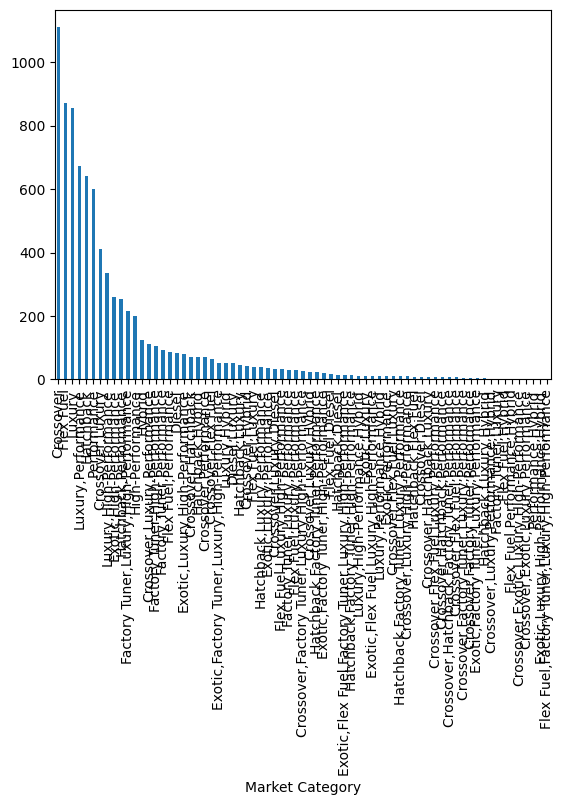

In [31]:
df['Market Category'].value_counts().plot(kind = 'bar')

In [32]:
df = df['Market Category'].fillna('Missing')

Text(0, 0.5, 'count')

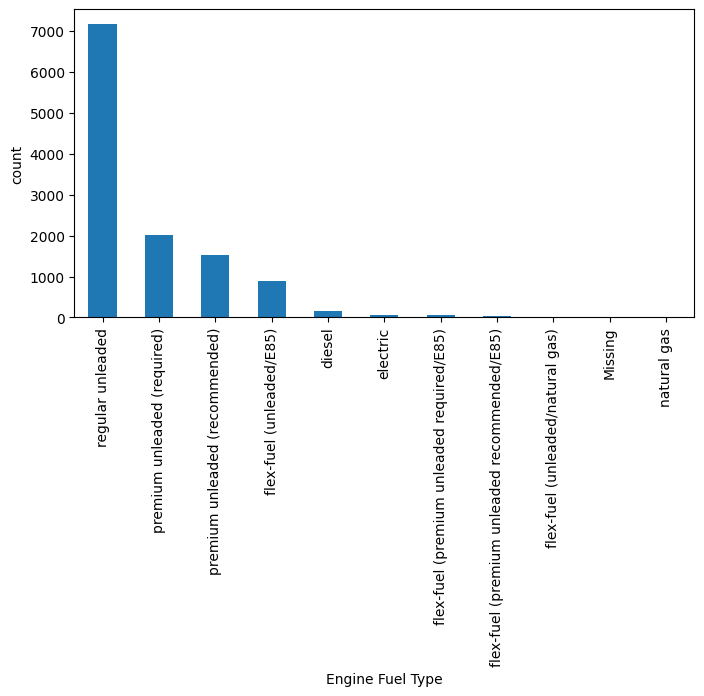

In [ ]:
df['Engine Fuel Type'].fillna('Missing').value_counts().plot(kind = 'bar', figsize = (8,4))
plt.xlabel('Engine Fuel Type')
plt.ylabel('count')
#plt.xticks(rotation = 45)

In [20]:
df.dropna(subset = ['Engine Fuel Type'], inplace = True)

In [40]:
df[missing_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 11911 entries, 0 to 11913
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine Fuel Type  11911 non-null  object 
 1   Engine HP         11842 non-null  float64
 2   Engine Cylinders  11881 non-null  float64
 3   Number of Doors   11905 non-null  float64
 4   Market Category   8172 non-null   object 
dtypes: float64(3), object(2)
memory usage: 558.3+ KB


In [39]:
df.dropna(subset = ['Engine Fuel Type'], inplace = True)

수치형 변수 결측값 처리 해주기

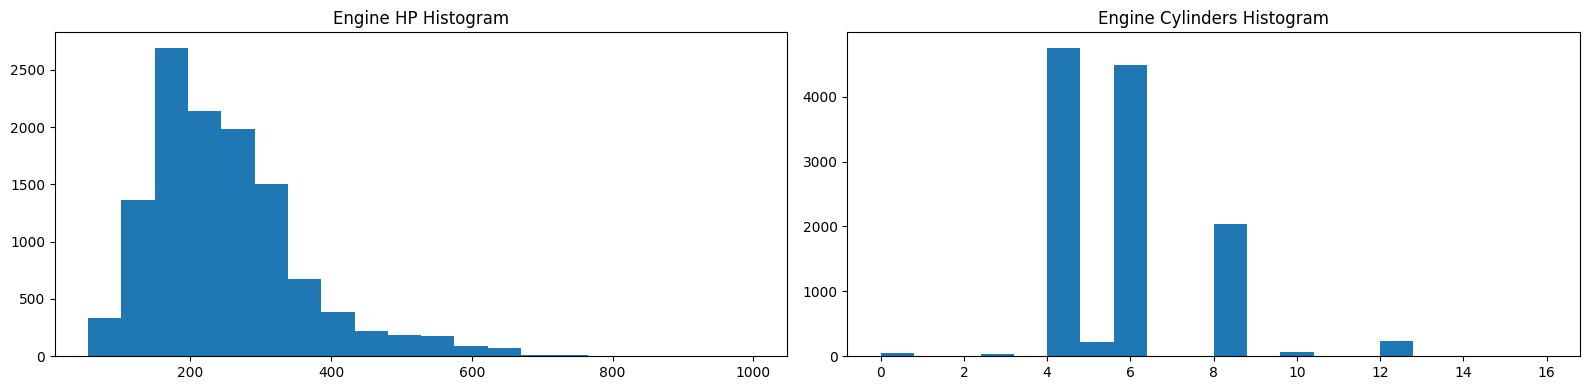

In [47]:
plt.figure(figsize = (16,4))

plt.subplot(1,2,1)
plt.hist(df['Engine HP'], bins = 20)
plt.title('Engine HP Histogram')

plt.subplot(1,2,2)
plt.hist(df['Engine Cylinders'], bins = 20)
plt.title('Engine Cylinders Histogram')

plt.tight_layout()

In [53]:
'''
Engine HP : 평균으로 결측 대체
Engine Cylinders : 최빈 값으로 대체
'''

df['Engine HP'].fillna(df['Engine HP'].mean(), inplace = True)
df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0], inplace = True)

C:\Users\jaeju\AppData\Local\Temp\ipykernel_11428\4078554780.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Engine HP'].fillna(df['Engine HP'].mean(), inplace = True)
C:\Users\jaeju\AppData\Local\Temp\ipykernel_11428\4078554780.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [51]:
df['Engine Cylinders'].mode()

0    4.0
Name: Engine Cylinders, dtype: float64

변수들 plot 보기

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11911 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11911 non-null  object 
 1   Model              11911 non-null  object 
 2   Year               11911 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11911 non-null  float64
 5   Engine Cylinders   11911 non-null  float64
 6   Transmission Type  11911 non-null  object 
 7   Driven_Wheels      11911 non-null  object 
 8   Number of Doors    11905 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11911 non-null  object 
 11  Vehicle Style      11911 non-null  object 
 12  highway MPG        11911 non-null  int64  
 13  city mpg           11911 non-null  int64  
 14  Popularity         11911 non-null  int64  
 15  MSRP               11911 non-null  int64  
dtypes: float64(3), int64(5), ob

In [73]:
numeric_cols = df.select_dtypes(include = ['float64', 'int64']).columns.tolist()
object_cols = df.select_dtypes(include = ['object']).columns.tolist()

In [58]:
numeric_cols

['Year',
 'Engine HP',
 'Engine Cylinders',
 'Number of Doors',
 'highway MPG',
 'city mpg',
 'Popularity',
 'MSRP']

In [62]:
aa = numeric_cols.remove('MSRP')

Boxplot

<Axes: >

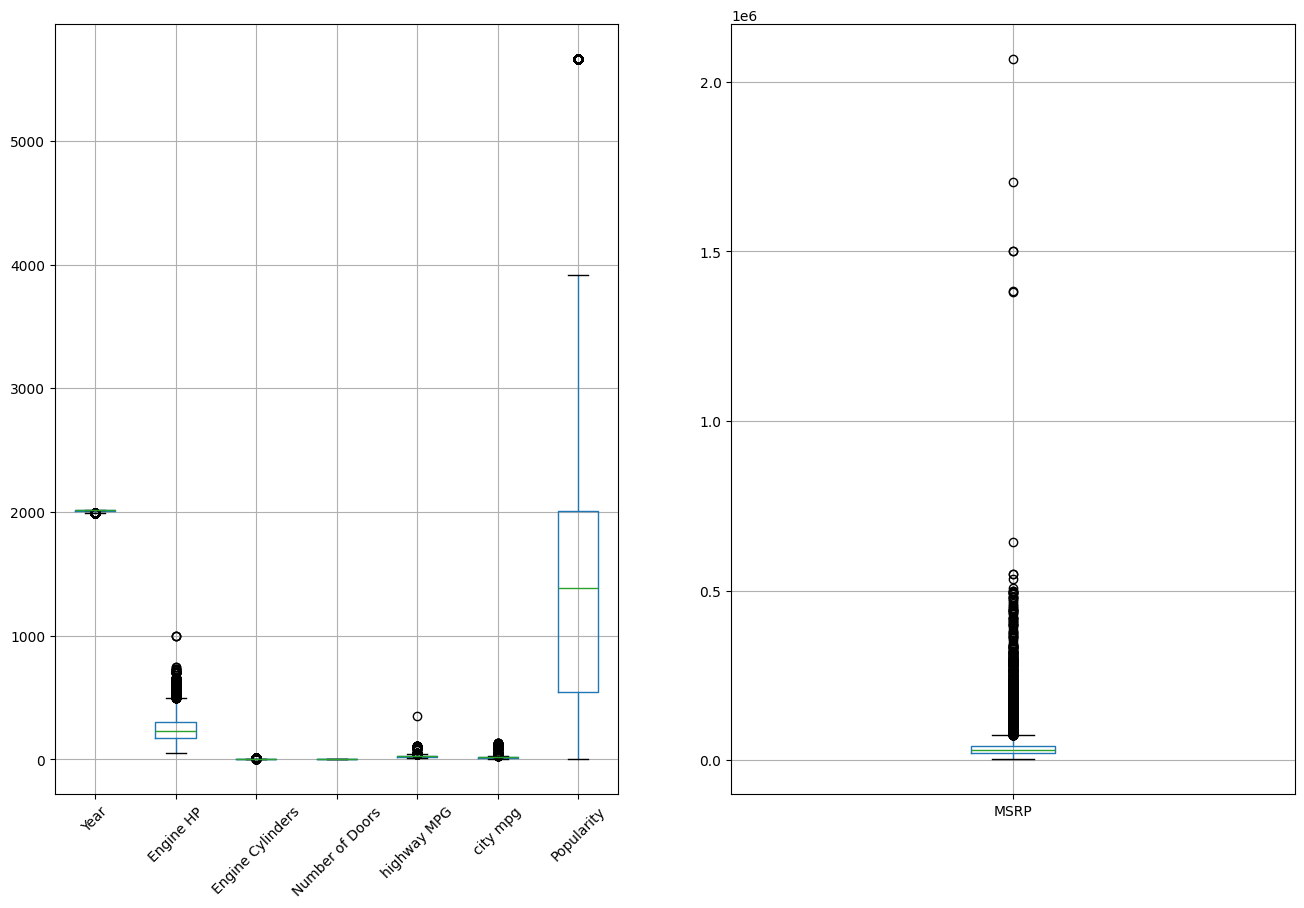

In [70]:
plt.figure(figsize = (16,10))

plt.subplot(1,2,1)
df.boxplot(column= numeric_cols)
plt.xticks(rotation = 45)

plt.subplot(1,2,2)
df.boxplot(column= ['MSRP'])

히스토그램

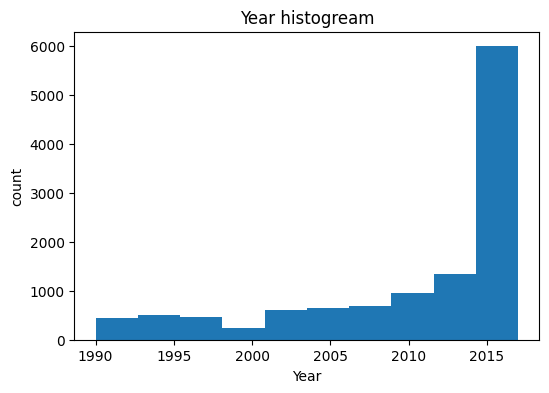

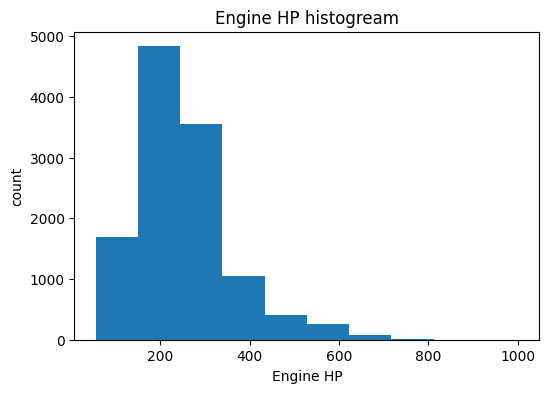

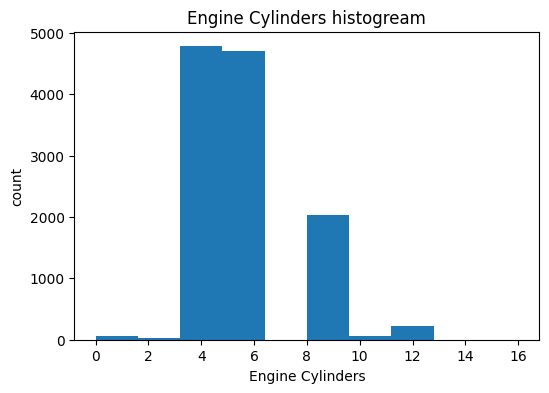

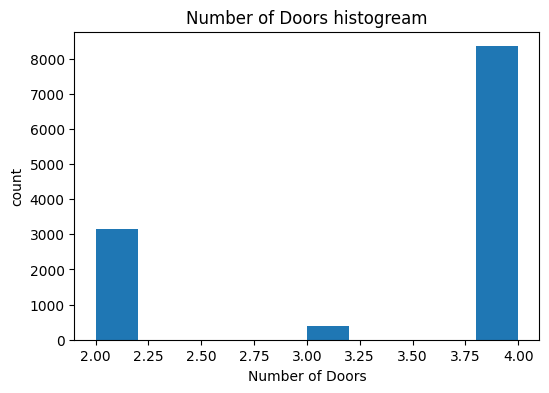

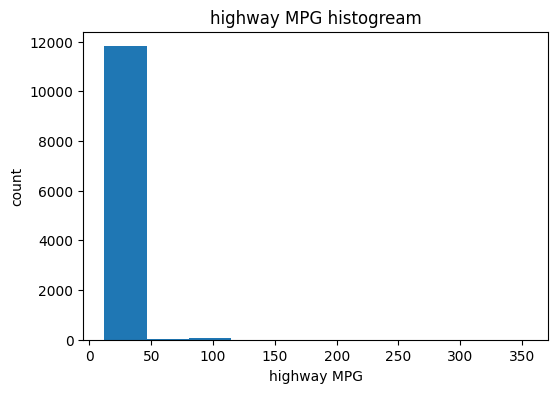

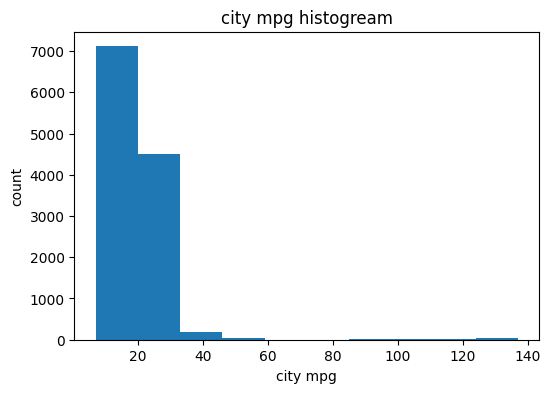

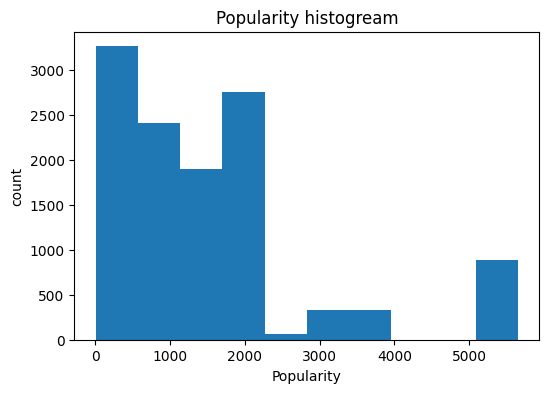

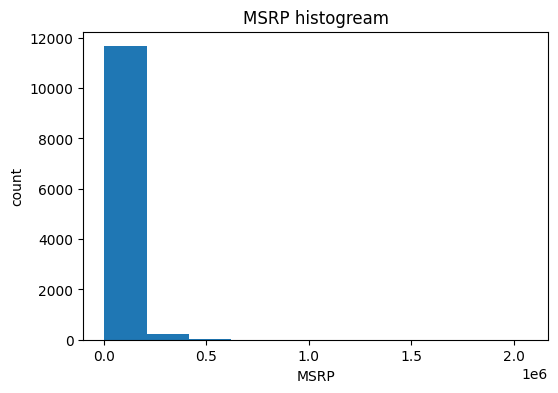

In [77]:
for col in numeric_cols:
    plt.figure(figsize = (6,4))
    plt.hist(df[col])
    plt.title(f'{col} histogream')
    plt.xlabel(col)
    plt.ylabel('count')

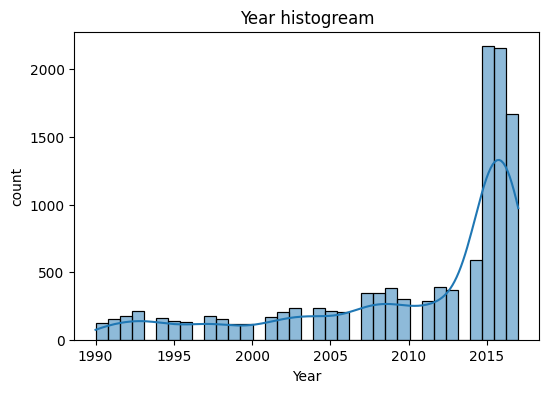

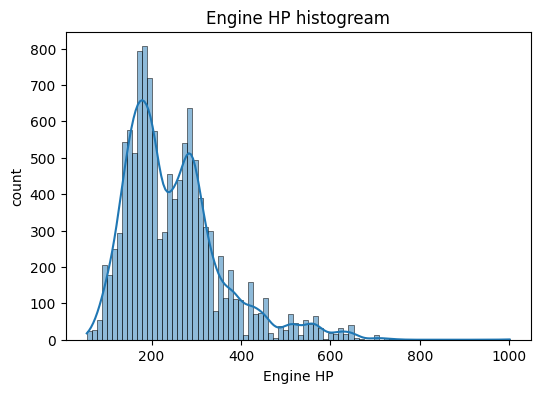

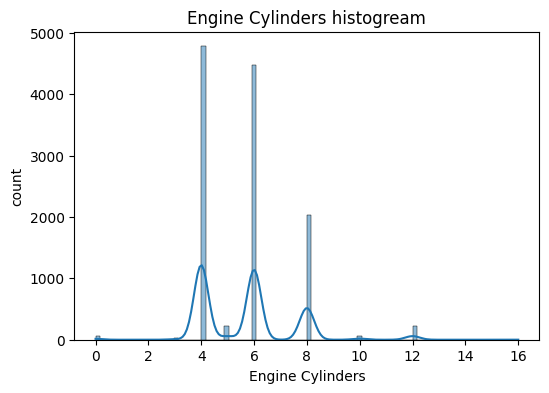

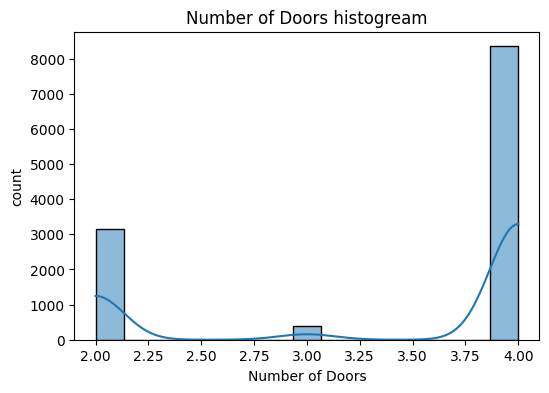

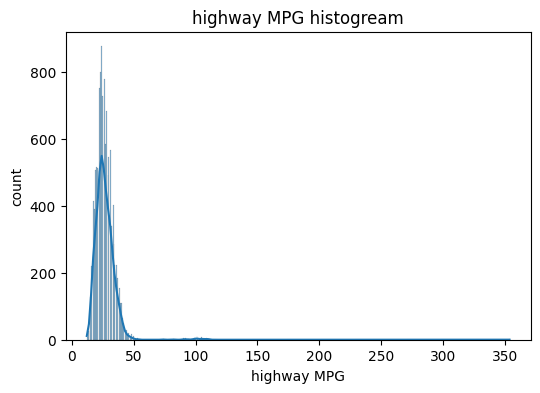

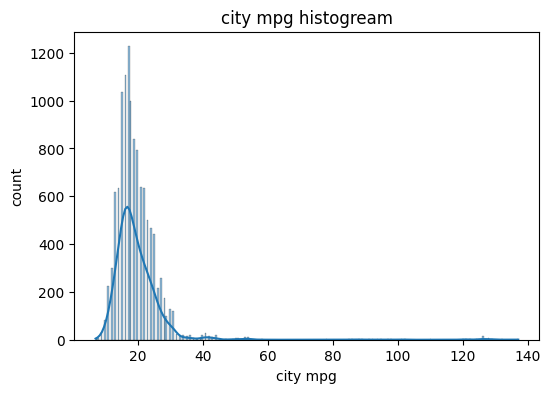

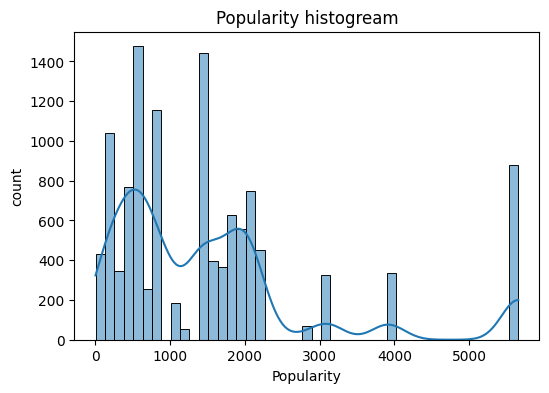

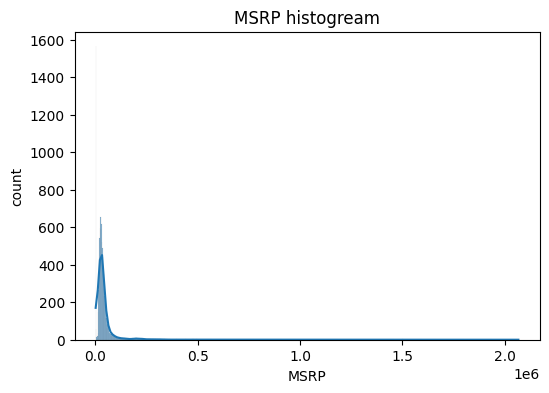

In [79]:
for col in numeric_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True)
    plt.title(f'{col} histogream')
    plt.xlabel(col)
    plt.ylabel('count')